In [1]:
# Load relevant imports here

# Data Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# add more as needed

#scipyLinks to an external site.
#statsmodelsLinks to an external site.

In [2]:
# Load the dataset (raw)
df_raw = pd.read_csv("US_Accidents_March23.csv")

# Keep working copy for cleaning and feature engineering (later)
df = df_raw.copy()


In [3]:
# Inspect structure

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [4]:
# Downsampling

df_sampled = df.sample(frac=0.01, random_state=42)

In [5]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     77284 non-null  object 
 1   Source                 77284 non-null  object 
 2   Severity               77284 non-null  int64  
 3   Start_Time             77284 non-null  object 
 4   End_Time               77284 non-null  object 
 5   Start_Lat              77284 non-null  float64
 6   Start_Lng              77284 non-null  float64
 7   End_Lat                43315 non-null  float64
 8   End_Lng                43315 non-null  float64
 9   Distance(mi)           77284 non-null  float64
 10  Description            77284 non-null  object 
 11  Street                 77157 non-null  object 
 12  City                   77281 non-null  object 
 13  County                 77284 non-null  object 
 14  State                  77284 non-null  object 
 15 

In [6]:
# Convert data types and create new columns

# Convert datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")

# Create new features
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Duration_min"] = (pd.to_datetime(df["End_Time"]) - df["Start_Time"]).dt.total_seconds() / 60



# Convert datetime
df_sampled["Start_Time"] = pd.to_datetime(df_sampled["Start_Time"], errors="coerce")
df_sampled["End_Time"] = pd.to_datetime(df_sampled["End_Time"], errors="coerce")

# Create new features
df_sampled["Hour"] = df_sampled["Start_Time"].dt.hour
df_sampled["DayOfWeek"] = df_sampled["Start_Time"].dt.dayofweek
df_sampled["Duration_min"] = (pd.to_datetime(df_sampled["End_Time"]) - df_sampled["Start_Time"]).dt.total_seconds() / 60



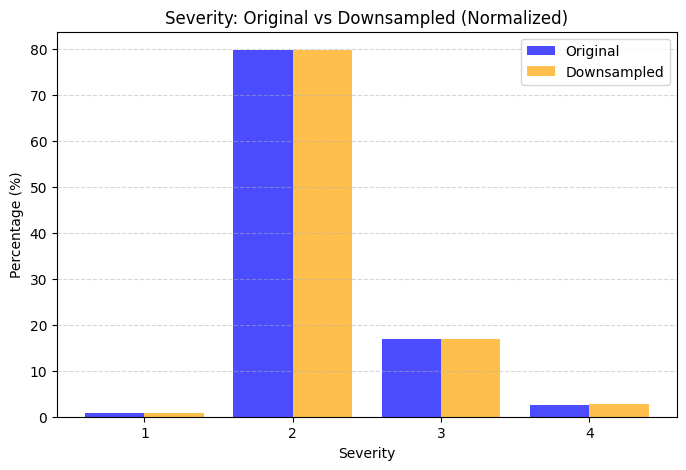

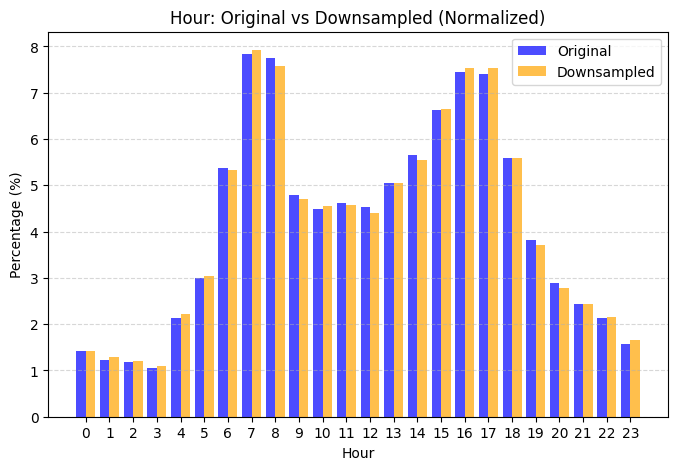

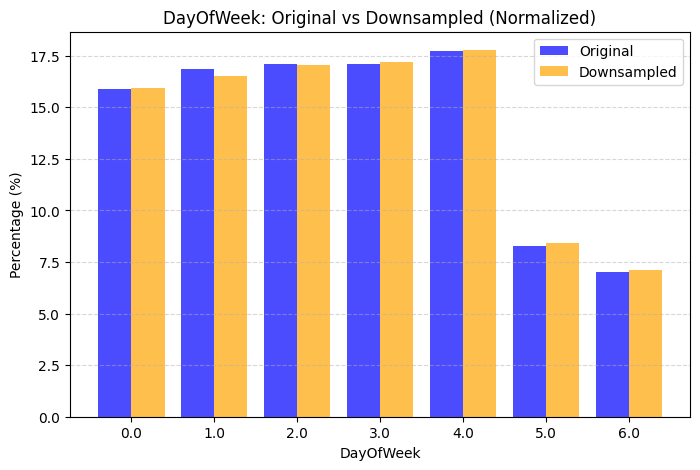

In [7]:
# Compare downsampled data with original data in terms of target variable and some features

# Features to compare
features = ['Severity', 'Hour', 'DayOfWeek']

for col in features:
    plt.figure(figsize=(8,5))
    
    if df[col].dtype in ['int64', 'float64'] and col != 'Hour':
        # Discrete numeric (Severity)
        orig_counts = df[col].value_counts(normalize=True).sort_index()
        sample_counts = df_sampled[col].value_counts(normalize=True).sort_index()
        x = np.arange(len(orig_counts))
        width = 0.4
        
        plt.bar(x - width/2, orig_counts.values*100, width=width, alpha=0.7, label='Original', color='blue')
        plt.bar(x + width/2, sample_counts.values*100, width=width, alpha=0.7, label='Downsampled', color='orange')
        plt.xticks(x, orig_counts.index)
        plt.ylabel('Percentage (%)')
    
    elif col == 'Hour':
        # Hours (0–23)
        bins = np.arange(0,25)
        # Compute histogram counts and normalize to percentage
        orig_hist, _ = np.histogram(df[col], bins=bins)
        sample_hist, _ = np.histogram(df_sampled[col], bins=bins)
        orig_hist = orig_hist / orig_hist.sum() * 100
        sample_hist = sample_hist / sample_hist.sum() * 100
        
        plt.bar(bins[:-1]-0.2, orig_hist, width=0.4, alpha=0.7, label='Original', color='blue')
        plt.bar(bins[:-1]+0.2, sample_hist, width=0.4, alpha=0.7, label='Downsampled', color='orange')
        plt.xticks(range(0,24))
        plt.ylabel('Percentage (%)')
    
    else:
        # Categorical (DayOfWeek)
        orig_counts = df[col].value_counts(normalize=True).sort_index()
        sample_counts = df_sampled[col].value_counts(normalize=True).sort_index()
        x = np.arange(len(orig_counts))
        width = 0.4
        
        plt.bar(x - width/2, orig_counts.values*100, width=width, alpha=0.7, label='Original', color='blue')
        plt.bar(x + width/2, sample_counts.values*100, width=width, alpha=0.7, label='Downsampled', color='orange')
        plt.xticks(x, orig_counts.index)
        plt.ylabel('Percentage (%)')
    
    plt.title(f'{col}: Original vs Downsampled (Normalized)')
    plt.xlabel(col)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

The bar plots above visually show that downsampled dataset has very similar distributions when comparing target variable and the features Hour and DayOfWeek.

In [8]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     77284 non-null  object        
 1   Source                 77284 non-null  object        
 2   Severity               77284 non-null  int64         
 3   Start_Time             69811 non-null  datetime64[ns]
 4   End_Time               69811 non-null  datetime64[ns]
 5   Start_Lat              77284 non-null  float64       
 6   Start_Lng              77284 non-null  float64       
 7   End_Lat                43315 non-null  float64       
 8   End_Lng                43315 non-null  float64       
 9   Distance(mi)           77284 non-null  float64       
 10  Description            77284 non-null  object        
 11  Street                 77157 non-null  object        
 12  City                   77281 non-null  object        
 13

In [9]:
# Identify categorical vs numerical columns

# Categorical / object / boolean columns
categorical_cols = df_sampled.select_dtypes(include=["object", "bool"]).columns
print("Categorical columns:", list(categorical_cols))

for col in categorical_cols:
    print(f"{col}: {df_sampled[col].nunique()} unique values")

# Numerical columns
numerical_cols = df_sampled.select_dtypes(include=["int64", "float64"]).columns
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['ID', 'Source', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
ID: 77284 unique values
Source: 3 unique values
Description: 72271 unique values
Street: 27382 unique values
City: 5926 unique values
County: 1243 unique values
State: 49 unique values
Zipcode: 30204 unique values
Country: 1 unique values
Timezone: 4 unique values
Airport_Code: 1552 unique values
Weather_Timestamp: 62935 unique values
Wind_Direction: 24 unique values
Weather_Condition: 74 unique values
Amenity: 2 unique values
Bump: 2 unique values
Crossing: 2 unique values
Give_Way: 2 unique values
Junction: 2 unique values
No_Exit: 2 unique values

End_Lat                  33969
End_Lng                  33969
Precipitation(in)        22095
Wind_Chill(F)            20015
Duration_min              7473
DayOfWeek                 7473
Start_Time                7473
End_Time                  7473
Hour                      7473
Wind_Speed(mph)           5771
Wind_Direction            1776
Visibility(mi)            1746
Humidity(%)               1715
Weather_Condition         1699
Temperature(F)            1612
Pressure(in)              1378
Weather_Timestamp         1199
Nautical_Twilight          252
Sunrise_Sunset             252
Civil_Twilight             252
Astronomical_Twilight      252
Airport_Code               224
Street                     127
Timezone                    74
Zipcode                     14
City                         3
dtype: int64


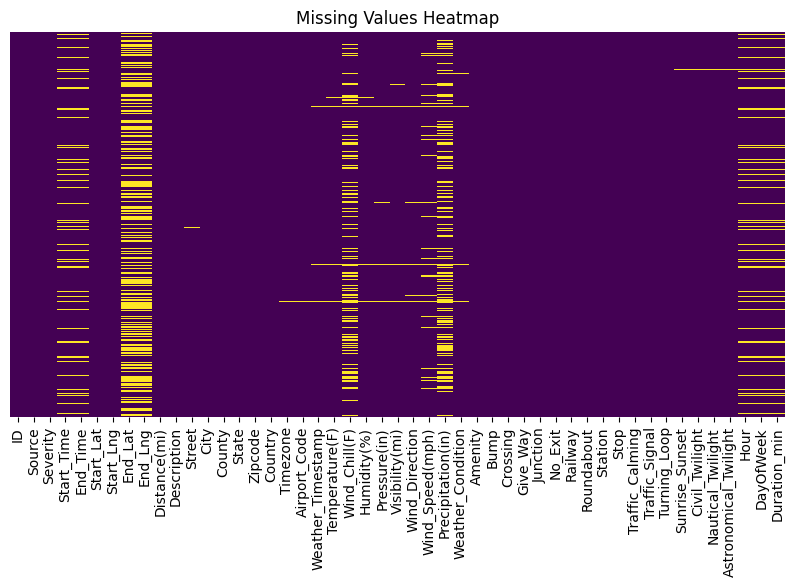

In [10]:
# Explore missing values

missing_counts = df_sampled.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

# Visual check
plt.figure(figsize=(10,5))
sns.heatmap(df_sampled.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


The number of missing values for each variable as shown numerically by the table above and visually by the heat map are quite large. It does not seem viable to eliminate all rows that may have missing data for all variables. Especially End_Lat and End_Lng have more than 30,000 missing values, while Precipitation(in) and Temperature(F) have missing values above 20,000. These four will be kept.

In [11]:
# Handle unnecessary columns

# Columns before drop
print("Columns before drop:", df_sampled.columns)

# Columns recommended to drop

cols_to_drop = [
    # Identifiers / free text
    "ID",               # unique record ID, not predictive
    "Description",      # long text, too unstructured for EDA
    "Street",           # high cardinality, not needed for analysis
    #"Number",           # street number, too granular
    "Airport_Code",     # rarely useful
    "Weather_Timestamp",# redundant if weather features exist
    "Country",           # all data is USA only
    
    ## Optional spatial columns (drop if not doing geospatial)
    "City",             # keep if doing city-level analysis
    "County",           # keep if doing county-level analysis
    "Zipcode",          # high cardinality
    #"TimeZone",         # usually redundant with Sunrise_Sunset or Hour

    "Civil_Twilight",    # redundant with Sunrise_Sunset
    "Nautical_Twilight", # redundant with Sunrise_Sunset
    "Astronomical_Twilight", # redundant with Sunrise_Sunset

    "End_Lat",
    "End_Lng",
    "Source"

]

# Drop the columns from your working DataFrame
df_sampled = df_sampled.drop(columns=cols_to_drop)

# Quick check
print("Columns after drop:", df_sampled.columns)


#cols_to_drop = ["Description", "ID", "Street", "End_Time"]
#df = df.drop(columns=cols_to_drop)# Inspect structure

df_sampled.info(memory_usage="deep")


Columns before drop: Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Hour', 'DayOfWeek', 'Duration_min'],
      dtype='object')
Columns after drop: Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'State', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressur

In [12]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           77284 non-null  int64         
 1   Start_Time         69811 non-null  datetime64[ns]
 2   End_Time           69811 non-null  datetime64[ns]
 3   Start_Lat          77284 non-null  float64       
 4   Start_Lng          77284 non-null  float64       
 5   Distance(mi)       77284 non-null  float64       
 6   State              77284 non-null  object        
 7   Timezone           77210 non-null  object        
 8   Temperature(F)     75672 non-null  float64       
 9   Wind_Chill(F)      57269 non-null  float64       
 10  Humidity(%)        75569 non-null  float64       
 11  Pressure(in)       75906 non-null  float64       
 12  Visibility(mi)     75538 non-null  float64       
 13  Wind_Direction     75508 non-null  object        
 14  Win

In [13]:
df_sampled.describe()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Hour,DayOfWeek,Duration_min
count,77284.000000,69811,69811,77284.000000,77284.000000,77284.000000,75672.000000,57269.000000,75569.000000,75906.000000,75538.000000,71513.000000,55189.000000,69811.000000,69811.000000,6.981100e+04
mean,2.212968,2020-03-21 23:14:53.904083968,2020-03-22 06:43:19.947959296,36.243557,-94.689142,0.562437,61.441102,57.990918,64.902209,29.531004,9.080745,7.683860,0.007832,12.254387,2.580811,4.484341e+02
min,1.000000,2016-02-08 06:49:27,2016-02-08 07:19:27,24.602680,-124.535726,0.000000,-89.000000,-89.000000,2.000000,3.010000,0.000000,0.000000,0.000000,0.000000,0.000000,5.766667e+00
25%,2.000000,2018-09-16 08:51:22.500000,2018-09-16 10:02:09,33.436031,-117.221422,0.000000,49.000000,42.000000,48.000000,29.360000,10.000000,4.600000,0.000000,8.000000,1.000000,3.000000e+01
50%,2.000000,2020-06-26 00:18:00,2020-06-26 07:48:36,35.862505,-87.768498,0.030000,64.000000,62.000000,67.000000,29.850000,10.000000,7.000000,0.000000,13.000000,3.000000,6.260000e+01
75%,2.000000,2021-10-29 12:11:59,2021-10-29 19:23:59.500000,40.116310,-80.345759,0.462250,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000,17.000000,4.000000,1.224917e+02
max,4.000000,2023-03-31 21:19:00,2023-03-31 22:27:13,48.995778,-68.226869,104.302000,162.000000,162.000000,100.000000,31.120000,80.000000,822.800000,10.000000,23.000000,6.000000,1.051257e+06
std,0.487646,NaN,NaN,5.055365,17.397620,1.741629,19.117553,22.519576,22.811676,1.020176,2.702361,6.125588,0.085949,5.477939,1.801187,1.397691e+04


In [14]:
df_sampled["Sunrise_Sunset"].value_counts()

Sunrise_Sunset
Day      53169
Night    23863
Name: count, dtype: int64

In [15]:
df_sampled["Wind_Direction"].value_counts()

Wind_Direction
CALM        9684
S           4080
SSW         3854
W           3848
NW          3834
WNW         3773
Calm        3731
SW          3666
WSW         3591
SSE         3555
NNW         3236
N           3103
SE          2926
E           2797
ESE         2721
NE          2653
ENE         2553
VAR         2454
NNE         2412
South       1816
West        1598
North       1472
Variable    1153
East         998
Name: count, dtype: int64

In [16]:
df_sampled["Weather_Condition"].value_counts()

Weather_Condition
Fair                 25552
Mostly Cloudy        10063
Clear                 8158
Cloudy                8121
Partly Cloudy         7121
                     ...  
Tornado                  1
Rain Showers             1
Smoke / Windy            1
Light Rain Shower        1
Ice Pellets              1
Name: count, Length: 74, dtype: int64

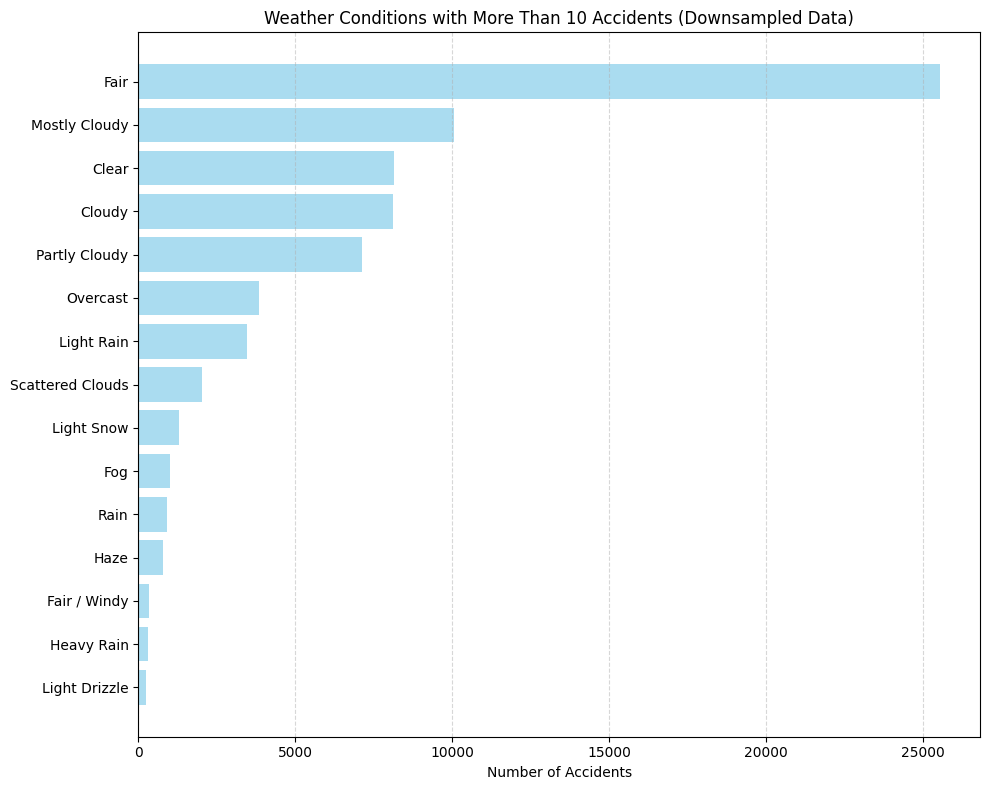

In [17]:

# Count occurrences
weather_counts = df_sampled["Weather_Condition"].value_counts()

# Filter: only categories with >10 occurrences
weather_counts = weather_counts[weather_counts > 200]

# Sort for nicer plotting
weather_counts = weather_counts.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(weather_counts.index, weather_counts.values, color='skyblue', alpha=0.7)
plt.xlabel("Number of Accidents")
plt.title("Weather Conditions with More Than 10 Accidents (Downsampled Data)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
# Columns to convert
cat_cols = ['Severity', 'Hour', 'DayOfWeek']

for col in cat_cols:
    #df[col] = df[col].astype('category')
    df_sampled[col] = df_sampled[col].astype('category')  # also convert downsampled

In [19]:
# Columns to convert
cat_cols = ['Severity', 'Hour', 'DayOfWeek', 'State', 'Timezone', 'Sunrise_Sunset']

# Convert in both original and downsampled datasets
for col in cat_cols:
   # df[col] = df[col].astype('category')
    df_sampled[col] = df_sampled[col].astype('category')

In [20]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           77284 non-null  category      
 1   Start_Time         69811 non-null  datetime64[ns]
 2   End_Time           69811 non-null  datetime64[ns]
 3   Start_Lat          77284 non-null  float64       
 4   Start_Lng          77284 non-null  float64       
 5   Distance(mi)       77284 non-null  float64       
 6   State              77284 non-null  category      
 7   Timezone           77210 non-null  category      
 8   Temperature(F)     75672 non-null  float64       
 9   Wind_Chill(F)      57269 non-null  float64       
 10  Humidity(%)        75569 non-null  float64       
 11  Pressure(in)       75906 non-null  float64       
 12  Visibility(mi)     75538 non-null  float64       
 13  Wind_Direction     75508 non-null  object        
 14  Win

In [23]:
# Columns to remove
cols_to_drop = ['Weather_Condition', 'Wind_Direction']

# Drop from original and downsampled datasets
#df = df.drop(columns=cols_to_drop)
df_sampled = df_sampled.drop(columns=cols_to_drop)

In [24]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           77284 non-null  category      
 1   Start_Time         69811 non-null  datetime64[ns]
 2   End_Time           69811 non-null  datetime64[ns]
 3   Start_Lat          77284 non-null  float64       
 4   Start_Lng          77284 non-null  float64       
 5   Distance(mi)       77284 non-null  float64       
 6   State              77284 non-null  category      
 7   Timezone           77210 non-null  category      
 8   Temperature(F)     75672 non-null  float64       
 9   Wind_Chill(F)      57269 non-null  float64       
 10  Humidity(%)        75569 non-null  float64       
 11  Pressure(in)       75906 non-null  float64       
 12  Visibility(mi)     75538 non-null  float64       
 13  Wind_Speed(mph)    71513 non-null  float64       
 14  Pre

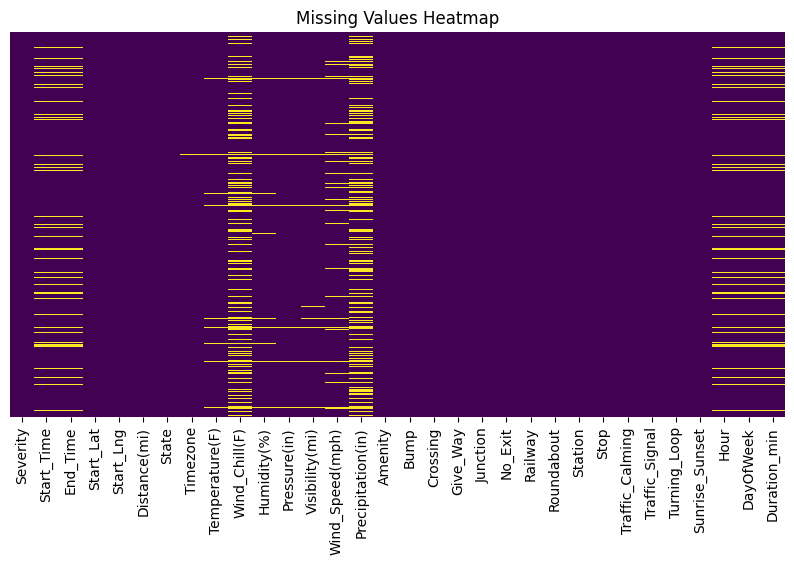

In [25]:

# Visual check
plt.figure(figsize=(10,5))
sns.heatmap(df_sampled.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [26]:
df_sampled.shape

(77284, 32)

In [27]:
length = df_sampled.shape[0]
print(length)

77284


In [28]:
df_sampled.isnull().count()

Severity             77284
Start_Time           77284
End_Time             77284
Start_Lat            77284
Start_Lng            77284
Distance(mi)         77284
State                77284
Timezone             77284
Temperature(F)       77284
Wind_Chill(F)        77284
Humidity(%)          77284
Pressure(in)         77284
Visibility(mi)       77284
Wind_Speed(mph)      77284
Precipitation(in)    77284
Amenity              77284
Bump                 77284
Crossing             77284
Give_Way             77284
Junction             77284
No_Exit              77284
Railway              77284
Roundabout           77284
Station              77284
Stop                 77284
Traffic_Calming      77284
Traffic_Signal       77284
Turning_Loop         77284
Sunrise_Sunset       77284
Hour                 77284
DayOfWeek            77284
Duration_min         77284
dtype: int64

In [29]:
null_count = df['Visibility(mi)'].isnull().sum()
print(null_count)

177098


In [30]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           77284 non-null  category      
 1   Start_Time         69811 non-null  datetime64[ns]
 2   End_Time           69811 non-null  datetime64[ns]
 3   Start_Lat          77284 non-null  float64       
 4   Start_Lng          77284 non-null  float64       
 5   Distance(mi)       77284 non-null  float64       
 6   State              77284 non-null  category      
 7   Timezone           77210 non-null  category      
 8   Temperature(F)     75672 non-null  float64       
 9   Wind_Chill(F)      57269 non-null  float64       
 10  Humidity(%)        75569 non-null  float64       
 11  Pressure(in)       75906 non-null  float64       
 12  Visibility(mi)     75538 non-null  float64       
 13  Wind_Speed(mph)    71513 non-null  float64       
 14  Pre

In [31]:

# Total number of rows
n_rows = len(df_sampled)

# Compute null counts and percentages
null_summary = pd.DataFrame({
    'Null_Count': df_sampled.isnull().sum(),
    'Null_Percent': df_sampled.isnull().mean() * 100
})

# Optional: sort by most missing values
null_summary = null_summary.sort_values(by='Null_Count', ascending=False)

print(null_summary)

                   Null_Count  Null_Percent
Precipitation(in)       22095     28.589359
Wind_Chill(F)           20015     25.897987
Duration_min             7473      9.669531
End_Time                 7473      9.669531
DayOfWeek                7473      9.669531
Hour                     7473      9.669531
Start_Time               7473      9.669531
Wind_Speed(mph)          5771      7.467264
Visibility(mi)           1746      2.259200
Humidity(%)              1715      2.219088
Temperature(F)           1612      2.085813
Pressure(in)             1378      1.783034
Sunrise_Sunset            252      0.326070
Timezone                   74      0.095751
Railway                     0      0.000000
Turning_Loop                0      0.000000
Traffic_Signal              0      0.000000
Traffic_Calming             0      0.000000
Stop                        0      0.000000
Station                     0      0.000000
Roundabout                  0      0.000000
Severity                    0   

In [32]:
# Handle missing values

# Drop rows with missing values
df_sampled = df_sampled.dropna(subset=["Start_Time",
                       "End_Time",


                       
                       #"City",
                       #"Zipcode",
                       "Timezone",
                       "Temperature(F)",
                       #"Wind_Chill(F)",
                       "Humidity(%)",
                       "Pressure(in)",
                       "Visibility(mi)",
                       #"Wind_Direction",
                       "Wind_Speed(mph)",
                       #"Precipitation(in)",
                       #"Weather_Condition",
                       
                       "Sunrise_Sunset",

                       "Hour",
                       "DayOfWeek",
                       "Duration_min"
                      ])



In [33]:
df_sampled.shape

(63571, 32)

In [34]:
length_after = df_sampled.shape[0]
print(length_after)

63571


In [35]:
length_reduction = (length - length_after) / length *100
print(length_reduction) # in percent

17.743646809171366


In [36]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 63571 entries, 7133276 to 6135831
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           63571 non-null  category      
 1   Start_Time         63571 non-null  datetime64[ns]
 2   End_Time           63571 non-null  datetime64[ns]
 3   Start_Lat          63571 non-null  float64       
 4   Start_Lng          63571 non-null  float64       
 5   Distance(mi)       63571 non-null  float64       
 6   State              63571 non-null  category      
 7   Timezone           63571 non-null  category      
 8   Temperature(F)     63571 non-null  float64       
 9   Wind_Chill(F)      49635 non-null  float64       
 10  Humidity(%)        63571 non-null  float64       
 11  Pressure(in)       63571 non-null  float64       
 12  Visibility(mi)     63571 non-null  float64       
 13  Wind_Speed(mph)    63571 non-null  float64       
 14  Pre

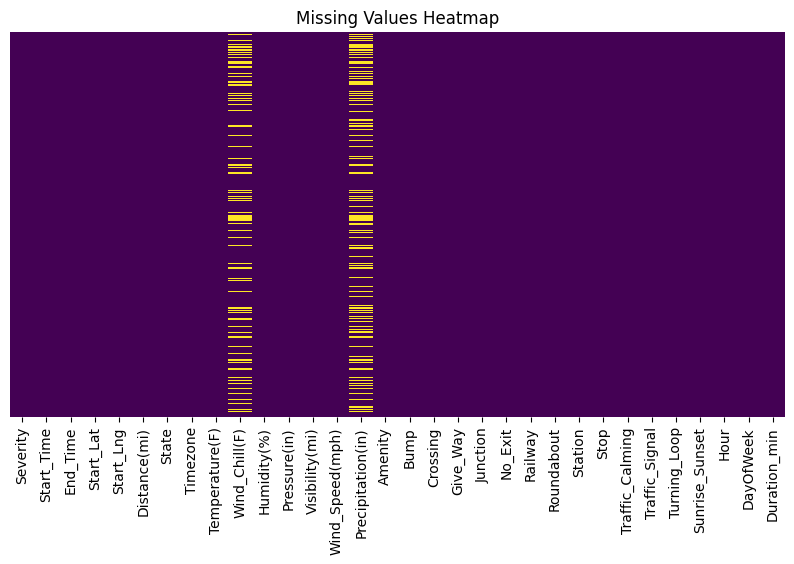

In [37]:

# Visual check
plt.figure(figsize=(10,5))
sns.heatmap(df_sampled.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [38]:
df_sampled.describe(include='all')

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),State,Timezone,Temperature(F),Wind_Chill(F),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Hour,DayOfWeek,Duration_min
count,63571.0,63571,63571,63571.000000,63571.000000,63571.000000,63571,63571,63571.000000,49635.000000,...,63571,63571,63571,63571,63571,63571,63571,63571.0,63571.0,6.357100e+04
unique,4.0,NaN,NaN,NaN,NaN,NaN,49,4,NaN,NaN,...,2,2,2,2,2,1,2,24.0,7.0,NaN
top,2.0,NaN,NaN,NaN,NaN,NaN,CA,US/Eastern,NaN,NaN,...,False,False,False,False,False,False,Day,16.0,4.0,NaN
freq,49981.0,NaN,NaN,NaN,NaN,NaN,13844,29281,NaN,NaN,...,63567,61986,61868,63506,53836,63571,44349,4984.0,11336.0,NaN
mean,NaN,2020-05-06 07:19:26.763744,2020-05-06 14:53:44.358339584,36.240886,-94.572104,0.526848,NaN,NaN,61.728475,57.796549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.542932e+02
min,NaN,2016-02-08 06:49:27,2016-02-08 07:19:27,24.602680,-124.535726,0.000000,NaN,NaN,-25.000000,-41.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.766667e+00
25%,NaN,2018-12-13 17:20:47.500000,2018-12-13 17:51:09,33.376931,-117.146523,0.000000,NaN,NaN,49.000000,42.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.100000e+01
50%,NaN,2020-10-06 06:33:11,2020-10-06 09:00:24,35.834835,-87.800964,0.010000,NaN,NaN,64.000000,62.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.156667e+01
75%,NaN,2021-11-15 19:30:25.500000,2021-11-16 08:29:02,40.161529,-80.388293,0.400000,NaN,NaN,76.000000,75.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.231667e+02
max,NaN,2023-03-31 21:19:00,2023-03-31 22:27:13,48.995778,-68.226869,104.302000,NaN,NaN,162.000000,162.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.051257e+06


In [39]:
# Identify categorical vs numerical columns

# Categorical / object / boolean columns
categorical_cols = df_sampled.select_dtypes(include=["object", "bool"]).columns
print("Categorical columns:", list(categorical_cols))

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# Numerical columns
numerical_cols = df_sampled.select_dtypes(include=["int64", "float64"]).columns
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']
Amenity: 2 unique values
Bump: 2 unique values
Crossing: 2 unique values
Give_Way: 2 unique values
Junction: 2 unique values
No_Exit: 2 unique values
Railway: 2 unique values
Roundabout: 2 unique values
Station: 2 unique values
Stop: 2 unique values
Traffic_Calming: 2 unique values
Traffic_Signal: 2 unique values
Turning_Loop: 1 unique values
Numerical columns: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Duration_min']


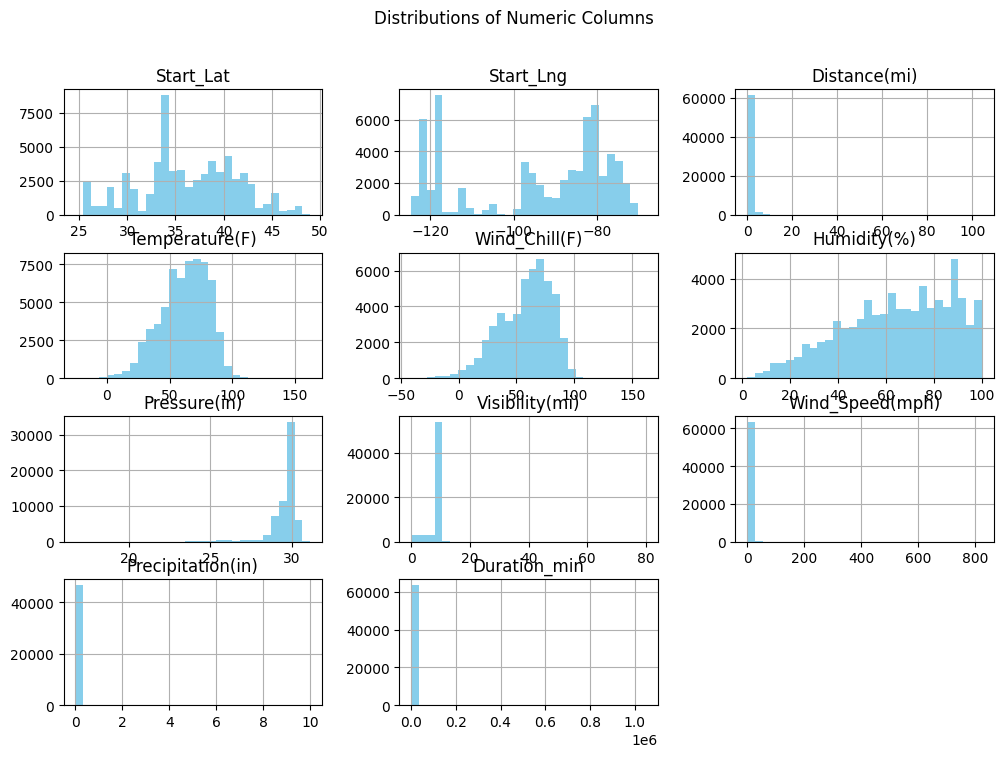

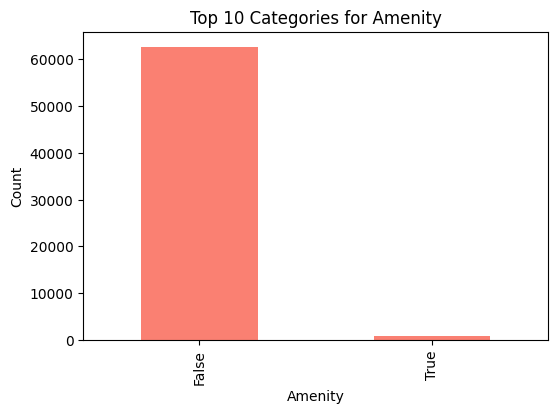

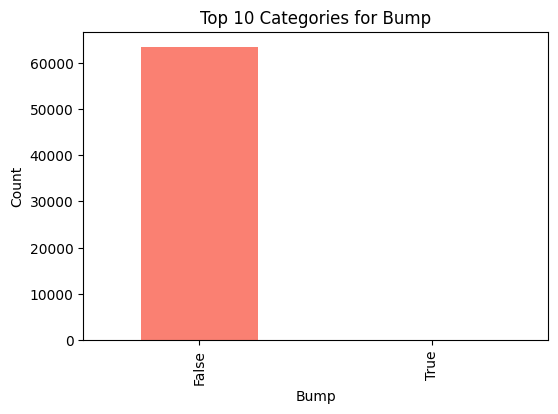

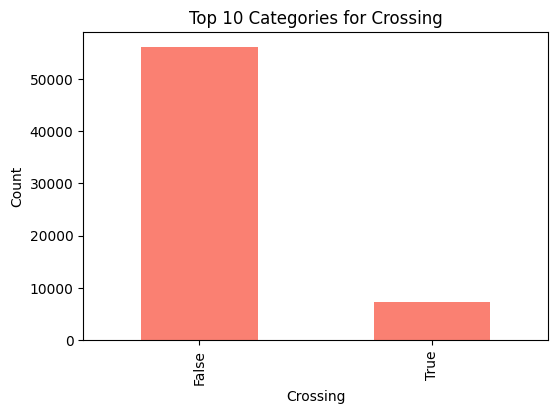

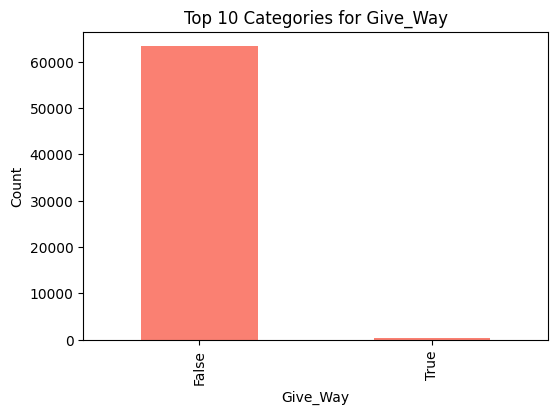

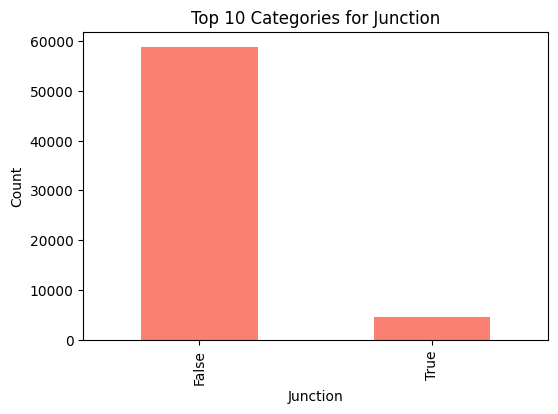

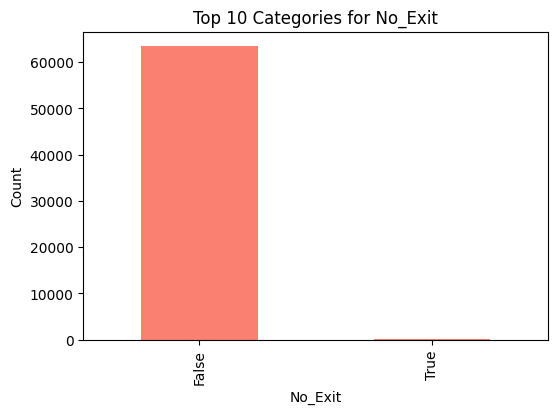

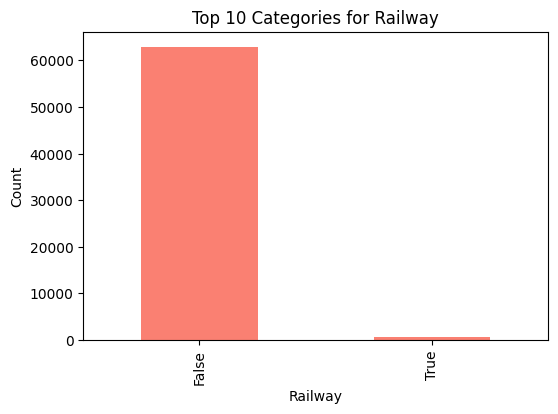

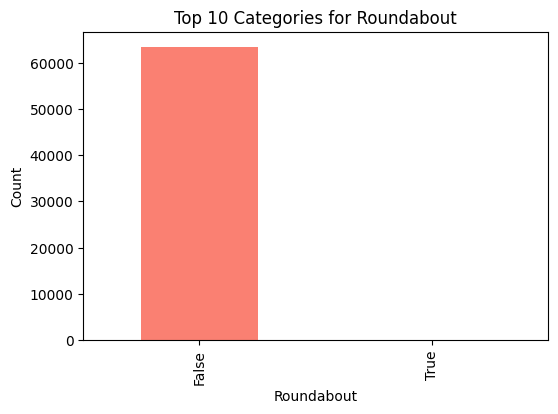

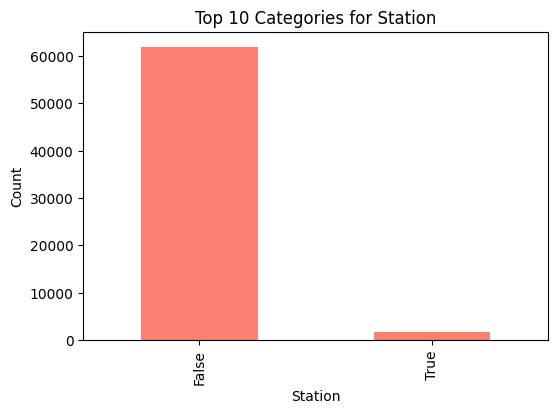

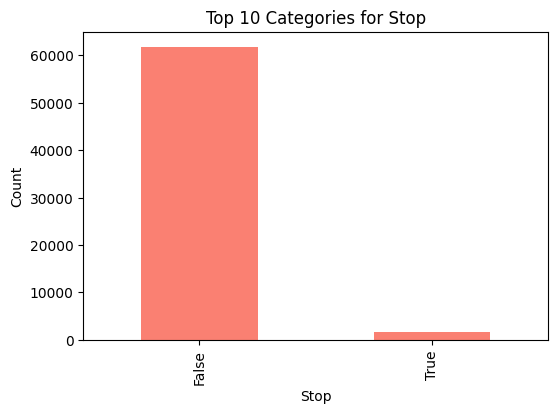

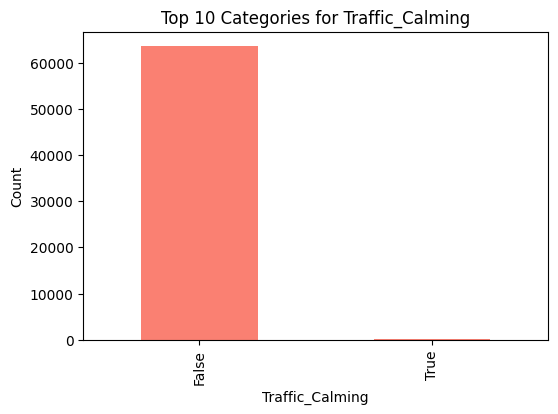

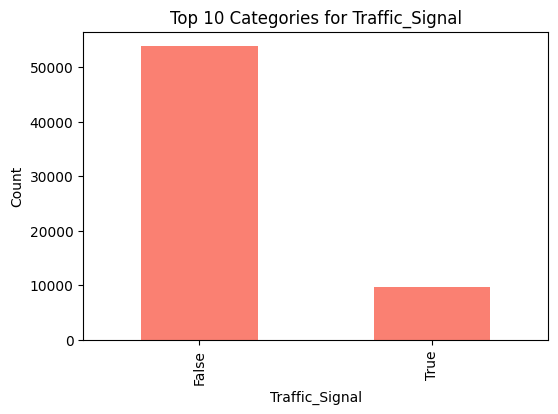

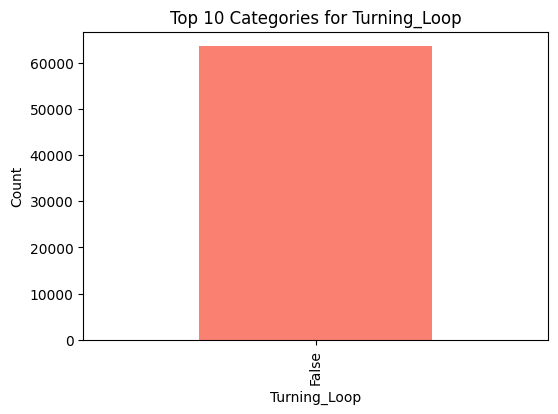

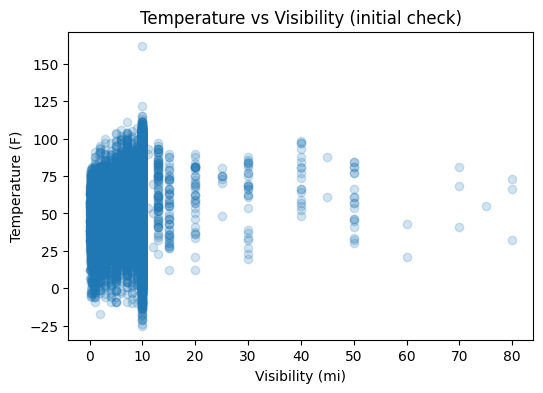

In [76]:
# Distribution of numeric columns

df_sampled[numerical_cols].hist(bins=30, figsize=(12,8), color='skyblue')
plt.suptitle("Distributions of Numeric Columns")
plt.show()

# Count of categorical columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df_sampled[col].value_counts().head(10).plot(kind='bar', color='salmon')
    plt.title(f"Top 10 Categories for {col}")
    plt.ylabel("Count")
    plt.show()

# Scatter plot for initial insights

plt.figure(figsize=(6,4))
plt.scatter(df_sampled["Visibility(mi)"], df_sampled["Temperature(F)"], alpha=0.2)
plt.xlabel("Visibility (mi)")
plt.ylabel("Temperature (F)")
plt.title("Temperature vs Visibility (initial check)")
plt.show()

In [77]:
# Select only numeric columns
df_num = df_sampled.select_dtypes(include=['int64', 'float64'])

# Compute min and max
min_vals = df_num.min()
max_vals = df_num.max()

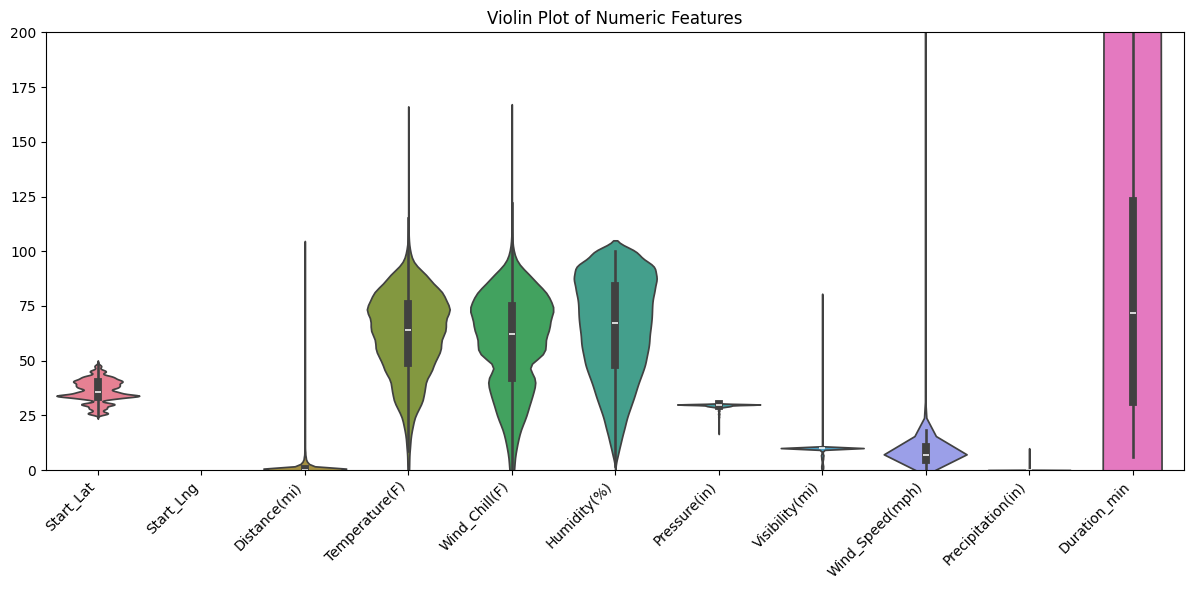

In [82]:

# Select numeric columns
df_num = df_sampled.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,6))
sns.violinplot(data=df_num)

plt.xticks(rotation=45, ha='right')
plt.title("Violin Plot of Numeric Features")
plt.tight_layout()
plt.ylim(0,200)
plt.show()

In [83]:
# Select numeric columns
df_num = df_sampled.select_dtypes(include=['int64', 'float64'])

# Get min and max
min_max = df_num.agg(['min', 'max']).T

print(min_max)

                          min           max
Start_Lat           24.602680  4.899578e+01
Start_Lng         -124.535726 -6.822687e+01
Distance(mi)         0.000000  1.043020e+02
Temperature(F)     -25.000000  1.620000e+02
Wind_Chill(F)      -41.000000  1.620000e+02
Humidity(%)          2.000000  1.000000e+02
Pressure(in)        16.720000  3.112000e+01
Visibility(mi)       0.000000  8.000000e+01
Wind_Speed(mph)      0.000000  8.228000e+02
Precipitation(in)    0.000000  9.990000e+00
Duration_min         5.766667  1.051257e+06


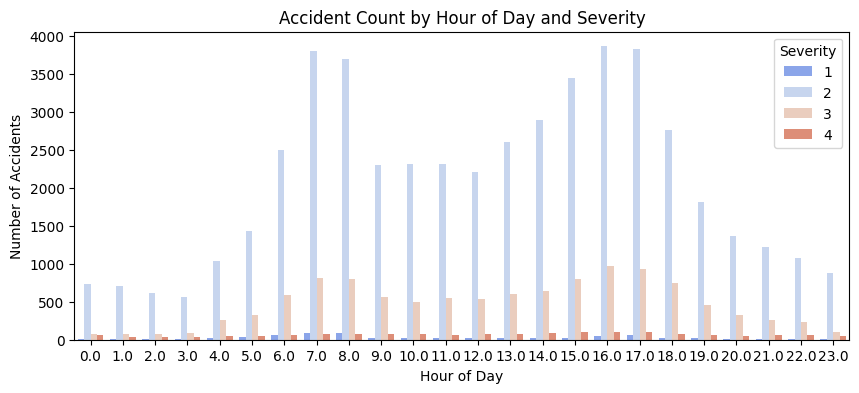

In [84]:
# Accidents by Hour

plt.figure(figsize=(10,4))
sns.countplot(x="Hour", hue="Severity", data=df_sampled, palette="coolwarm")
plt.title("Accident Count by Hour of Day and Severity")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

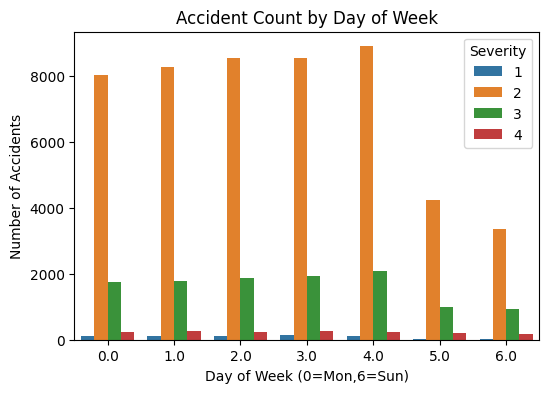

In [85]:
# Accidents by Day of Week

plt.figure(figsize=(6,4))
sns.countplot(x="DayOfWeek", hue="Severity", data=df_sampled)
plt.title("Accident Count by Day of Week")
plt.xlabel("Day of Week (0=Mon,6=Sun)")
plt.ylabel("Number of Accidents")
plt.show()

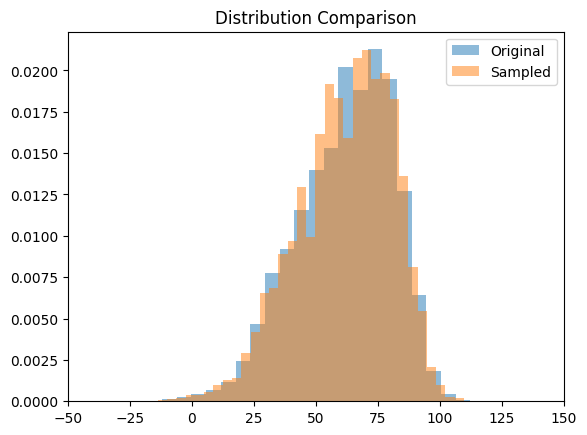

In [91]:


plt.hist(df['Temperature(F)'], bins=50, alpha=0.5, label='Original', density=True)
plt.hist(df_sampled['Temperature(F)'], bins=50, alpha=0.5, label='Sampled', density=True)

plt.legend()
plt.title("Distribution Comparison")
plt.xlim(-50,150)
plt.show()

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [ ]:

# ----------------------------
# 1. Drop unwanted columns
# ----------------------------
cols_to_drop = ['Weather_Condition', 'Wind_Direction', 'City']
df_sampled = df_sampled.drop(columns=cols_to_drop, errors='ignore')


In [ ]:

# ----------------------------
# 2. Convert to categorical
# ----------------------------
cat_cols = ['Severity', 'Hour', 'DayOfWeek', 'State', 'Timezone', 'Sunrise_Sunset']
for col in cat_cols:
    if col in df_sampled.columns:
        df_sampled[col] = df_sampled[col].astype('category')


In [98]:
df_sampled

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),State,Timezone,Temperature(F),Wind_Chill(F),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Hour,DayOfWeek,Duration_min
7133276,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,0.000,FL,US/Eastern,78.0,78.0,...,False,False,False,False,True,False,Day,9.0,4.0,60.000000
155993,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,0.000,GA,US/Eastern,91.0,NaN,...,False,False,False,False,False,False,Day,16.0,4.0,30.000000
1861414,3,2019-09-20 15:22:16,2019-09-20 15:56:00,47.118706,-122.556908,0.000,WA,US/Pacific,67.0,67.0,...,False,False,False,False,False,False,Day,15.0,4.0,33.733333
2021359,2,2019-06-03 16:55:43,2019-06-03 18:12:09,33.451355,-111.890343,0.000,AZ,US/Mountain,95.0,95.0,...,False,False,False,False,False,False,Day,16.0,0.0,76.433333
1157640,2,2021-02-04 12:48:21,2021-02-04 16:51:15,42.448910,-93.721138,7.770,IA,US/Central,19.0,1.0,...,False,False,False,False,False,False,Day,12.0,3.0,242.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6066201,2,2021-10-19 10:40:30,2021-10-19 11:39:30,34.056516,-81.130787,1.789,SC,US/Eastern,64.0,64.0,...,False,False,False,False,False,False,Day,10.0,1.0,59.000000
6426257,2,2021-02-06 03:37:00,2021-02-06 06:02:23,33.870817,-117.739437,0.552,CA,US/Pacific,39.0,36.0,...,False,False,False,False,False,False,Night,3.0,5.0,145.383333
5988057,2,2021-04-16 05:56:00,2021-04-16 16:38:03,34.067824,-118.031868,1.822,CA,US/Pacific,53.0,53.0,...,False,False,False,False,False,False,Night,5.0,4.0,642.050000
1466802,2,2020-05-21 17:56:01,2020-05-21 18:40:36,42.294025,-71.047272,0.000,MA,US/Eastern,71.0,71.0,...,False,False,False,False,False,False,Day,17.0,3.0,44.583333


In [99]:

# ----------------------------
# 3. One-hot encoding
# ----------------------------
#df_encoded = pd.get_dummies(df_sampled, columns=cat_cols)
df_encoded = pd.get_dummies(df_sampled, columns=cat_cols)

# Separate features and target
X = df_encoded.drop(columns=['Severity'])
y = df_encoded['Severity']


KeyError: "['Severity'] not found in axis"

In [ ]:

# ----------------------------
# 4. Train/test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:

# ----------------------------
# 5. Fit Random Forest
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1  # show progress
)
rf.fit(X_train, y_train)


In [ ]:

# ----------------------------
# 6. Feature importances
# ----------------------------
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(20))


In [ ]:

# ----------------------------
# 7. Plot top 20 feature importances
# ----------------------------
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:20][::-1], feat_imp['Importance'][:20][::-1], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [102]:
df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 63571 entries, 7133276 to 6135831
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           63571 non-null  category      
 1   Start_Time         63571 non-null  datetime64[ns]
 2   End_Time           63571 non-null  datetime64[ns]
 3   Start_Lat          63571 non-null  float64       
 4   Start_Lng          63571 non-null  float64       
 5   Distance(mi)       63571 non-null  float64       
 6   State              63571 non-null  category      
 7   Timezone           63571 non-null  category      
 8   Temperature(F)     63571 non-null  float64       
 9   Wind_Chill(F)      49635 non-null  float64       
 10  Humidity(%)        63571 non-null  float64       
 11  Pressure(in)       63571 non-null  float64       
 12  Visibility(mi)     63571 non-null  float64       
 13  Wind_Speed(mph)    63571 non-null  float64       
 14  Pre

In [103]:
# Drop columns we won't use
cols_to_drop = ['Severity', 'Start_Time', 'End_Time']
X = df_sampled.drop(columns=cols_to_drop)

# Target
y = df_sampled['Severity']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (63571, 29)
y shape: (63571,)


In [104]:
cat_cols = ['State', 'Timezone', 'Sunrise_Sunset', 'Hour', 'DayOfWeek']

X_encoded = pd.get_dummies(X, columns=cat_cols)

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (50856, 110)
X_test shape: (12715, 110)


In [106]:

# ----------------------------
# 5. Fit Random Forest
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1  # show progress
)
rf.fit(X_train, y_train)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.9s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [107]:

# ----------------------------
# 6. Feature importances
# ----------------------------
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(20))


ValueError: All arrays must be of the same length